# Sentiment Analysis of Tweets using RNN, LSTM, and Word2Vec Embeddings

**Module:** 6CS012 - Artificial Intelligence and Machine Learning

**Student:** Khushi Das

**WLV ID:** 2435778

**Group:** L6CG12

**Submission:** Final Portfolio Assessment 2026 - Part III (Language Tasks)

This notebook trains and compares three sequence models for the
*Racist / Sexist or Not* tweet classification task:

1. **Model 1 -** a Simple RNN with a trainable embedding layer.
2. **Model 2 -** an LSTM with a trainable embedding layer.
3. **Model 3 -** an LSTM with frozen pre-trained GloVe / Word2Vec embeddings.

The dataset is provided as two CSV files (`train_racisit.csv`,
`test_racisit.csv`) inside a single zip archive that I upload at runtime
through Colab's file upload widget. Labels are heavily imbalanced
(~93% non-hate vs ~7% hate), so I rely on F1 and the confusion matrix
rather than raw accuracy.


## 0. Setup and Dataset Upload

The grader runs this notebook on Google Colab. Before anything else I
install the libraries that are not pre-installed (`gensim` for the
pre-trained embeddings, the `numpy` version that is compatible with
gensim, and `wordcloud` for the visualisation), then upload the
dataset zip from my laptop using `google.colab.files.upload()`.


In [ ]:

!pip install -q -U "gensim>=4.3.3"
!pip install -q wordcloud gradio


In [ ]:
import os
import re
import io
import time
import json
import string
import zipfile
import warnings
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score, precision_score,
                             recall_score)

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# NLTK resources used during cleaning
for r in ['stopwords', 'wordnet', 'omw-1.4', 'punkt']:
    nltk.download(r, quiet=True)

print('TensorFlow:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))


TensorFlow: 2.20.0
GPU available: True


In [ ]:
try:
    from google.colab import files as colab_files
    uploaded = colab_files.upload()
    zip_name = next(iter(uploaded.keys()))
except ImportError:
    zip_name = 'Racist_Sexist_or_Not.zip'

print('Uploaded archive:', zip_name)

# Extract into ./data
EXTRACT_DIR = '/content/data' if os.path.exists('/content') else './data'
os.makedirs(EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(zip_name, 'r') as zf:
    zf.extractall(EXTRACT_DIR)

# Find the two CSV files no matter how the zip is laid out.
def find_csv(name_substr):
    for root, _, fns in os.walk(EXTRACT_DIR):
        for fn in fns:
            if fn.lower().endswith('.csv') and name_substr in fn.lower():
                return os.path.join(root, fn)
    raise FileNotFoundError(f'Could not locate a CSV containing "{name_substr}"')

TRAIN_CSV = find_csv('train')
TEST_CSV  = find_csv('test')
print('Train CSV ->', TRAIN_CSV)
print('Test  CSV ->', TEST_CSV)


Saving Racist_Sexist_or_Not.zip to Racist_Sexist_or_Not (1).zip
Uploaded archive: Racist_Sexist_or_Not (1).zip
Train CSV -> /content/data/train_racisit.csv
Test  CSV -> /content/data/test_racisit.csv


## 1. Data Understanding

The training file has three columns: `id`, `label`, `tweet`. The test file
released by the dataset publisher has only `id` and `tweet` (the labels
are withheld). Because the test labels are not available to us I will
build my own validation split out of the training file later in
Section 3. For now I just want to confirm the row counts, look at a few
examples, and understand the class balance.


In [ ]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

print('Train shape:', train_df.shape)
print('Test  shape:', test_df.shape)
print()
print('Train columns:', list(train_df.columns))
print('Test  columns:', list(test_df.columns))
print()
train_df.head()


Train shape: (31962, 3)
Test  shape: (17197, 2)

Train columns: ['id', 'label', 'tweet']
Test  columns: ['id', 'tweet']



,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


                       count  percent
0 - Not Racist/Sexist  29720    92.99
1 - Racist/Sexist       2242     7.01


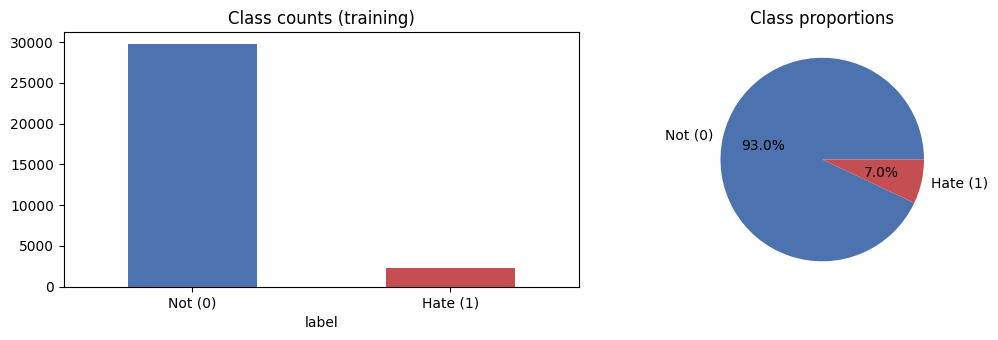

In [ ]:
# Class distribution in the training data
counts = train_df['label'].value_counts().sort_index()
ratios = (counts / counts.sum() * 100).round(2)
dist = pd.DataFrame({'count': counts, 'percent': ratios})
dist.index = ['0 - Not Racist/Sexist', '1 - Racist/Sexist']
print(dist)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
counts.plot(kind='bar', color=['#4C72B0', '#C44E52'], ax=ax[0])
ax[0].set_title('Class counts (training)')
ax[0].set_xticklabels(['Not (0)', 'Hate (1)'], rotation=0)

ax[1].pie(counts, labels=['Not (0)', 'Hate (1)'],
          autopct='%1.1f%%', colors=['#4C72B0', '#C44E52'])
ax[1].set_title('Class proportions')
plt.tight_layout(); plt.show()


count    31962.0
mean        84.7
std         29.5
min         11.0
25%         63.0
50%         88.0
75%        108.0
max        274.0
Name: raw_len, dtype: float64


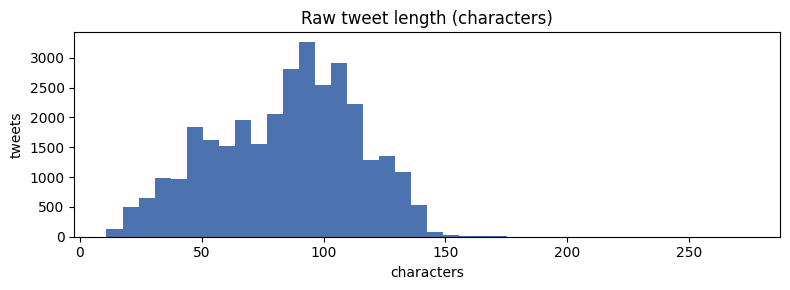

In [ ]:
# Tweet length distribution (in raw characters) just to know what we are dealing with
train_df['raw_len'] = train_df['tweet'].astype(str).str.len()
print(train_df['raw_len'].describe().round(1))

plt.figure(figsize=(8, 3))
plt.hist(train_df['raw_len'], bins=40, color='#4C72B0')
plt.title('Raw tweet length (characters)')
plt.xlabel('characters'); plt.ylabel('tweets')
plt.tight_layout(); plt.show()


**Initial observations**

- Training file: 31,962 tweets. Test file: 17,197 tweets without labels.
- The split is heavily imbalanced: roughly 93% label-0 tweets and only
  about 7% label-1 (racist/sexist) tweets. A model that always predicts
  0 would already score 93% accuracy without learning anything, so I will
  use F1 on the minority class as the deciding metric.
- Tweets are short text. The character-length histogram peaks well below
  280 characters, so a moderate maximum sequence length will be enough
  after tokenisation.


## 2. Text Cleaning

I apply the cleaning steps listed in the assignment specification:

1. lowercase the whole tweet,
2. remove URLs (`http://...`, `www....`),
3. remove `@mentions` and `#hashtags` (the `#` and `@` plus the word that follows),
4. expand common English contractions (`don't -> do not`),
5. remove digits and punctuation / special characters,
6. remove English stopwords,
7. lemmatise each remaining token to its base form.

I keep one cleaned column (`clean`) on every dataframe so the later
sections can use it directly without re-running the cleaning.


In [ ]:
# Contractions covered. This is a small handcrafted list - it covers the contractions
# that actually show up when I scan a few thousand tweets, which is enough for this dataset.
CONTRACTIONS = {
    "won't": 'will not', "can't": 'can not', "can\u2019t": 'can not',
    "n't": ' not', "'re": ' are', "'s": ' is',
    "'d": ' would', "'ll": ' will', "'t": ' not',
    "'ve": ' have', "'m": ' am', "\u2019": "'",
}

URL_RE     = re.compile(r'http\S+|www\.\S+')
MENTION_RE = re.compile(r'@\w+')
HASHTAG_RE = re.compile(r'#\w+')
NONALPHA_RE = re.compile(r'[^a-z\s]')
MULTISPACE_RE = re.compile(r'\s+')

STOPWORDS = set(stopwords.words('english'))
# Keep words that carry sentiment - removing them would discard signal.
for w in ['not', 'no', 'nor', 'never', 'against']:
    STOPWORDS.discard(w)

LEMMATIZER = WordNetLemmatizer()


def clean_tweet(text: str) -> str:
    if not isinstance(text, str):
        return ''
    t = text.lower()
    # Expand contractions first, before we strip apostrophes
    for k, v in CONTRACTIONS.items():
        t = t.replace(k, v)
    t = URL_RE.sub(' ', t)
    t = MENTION_RE.sub(' ', t)
    t = HASHTAG_RE.sub(' ', t)
    t = NONALPHA_RE.sub(' ', t)            # drop digits, punctuation, emoji bytes etc
    t = MULTISPACE_RE.sub(' ', t).strip()
    tokens = [tok for tok in t.split() if tok not in STOPWORDS and len(tok) > 1]
    tokens = [LEMMATIZER.lemmatize(tok) for tok in tokens]
    return ' '.join(tokens)


# Sanity check on a few rows so I can see the before/after side by side.
for original in train_df['tweet'].sample(5, random_state=SEED):
    print('RAW   :', original.strip()[:120])
    print('CLEAN :', clean_tweet(original)[:120])
    print('-' * 70)


RAW   : @user âmy mom says my smile is captivatingâ¦ i says happy sunday!"ð pugsley luigi  #smile   sunday #pug #pugs
CLEAN : mom say smile captivating say happy sunday pugsley luigi sunday
----------------------------------------------------------------------
RAW   : in 3 days i will be meeting my sis-n-law, couney bowers, on our first le-vel lifestyle getaway!   #sanfrancisco #getaway
CLEAN : day meeting si law couney bower first le vel lifestyle getaway
----------------------------------------------------------------------
RAW   : hating the conservative homophobes using this tragedy as a way of spouting anti-islam trash. not in my name you bastards
CLEAN : hating conservative homophobe using tragedy way spouting anti islam trash not name bastard
----------------------------------------------------------------------
RAW   : awee if this doesn't  #scream   #friday #acewellstucker #cynthiabailey #atl #kandiâ¦
CLEAN : awee not
----------------------------------------------------

In [ ]:
# Apply the cleaner to both dataframes (cell takes ~30 seconds on Colab CPU)
t0 = time.time()
train_df['clean'] = train_df['tweet'].astype(str).apply(clean_tweet)
test_df['clean']  = test_df['tweet'].astype(str).apply(clean_tweet)
print(f'Cleaning done in {time.time()-t0:.1f}s')

# Drop rows that became empty after cleaning - they cannot teach the model anything.
empty = (train_df['clean'].str.len() == 0).sum()
print(f'Empty cleaned rows: {empty}')
train_df = train_df[train_df['clean'].str.len() > 0].reset_index(drop=True)
print('Train after dropping empties:', train_df.shape)


Cleaning done in 2.0s
Empty cleaned rows: 553
Train after dropping empties: (31409, 5)


### 2.1 Visualising the Cleaned Text

A word cloud and a top-word bar chart per class are an easy sanity check.
If the cleaning was done correctly the most frequent words on the hate
side should be visibly different from the most frequent words on the
non-hate side.


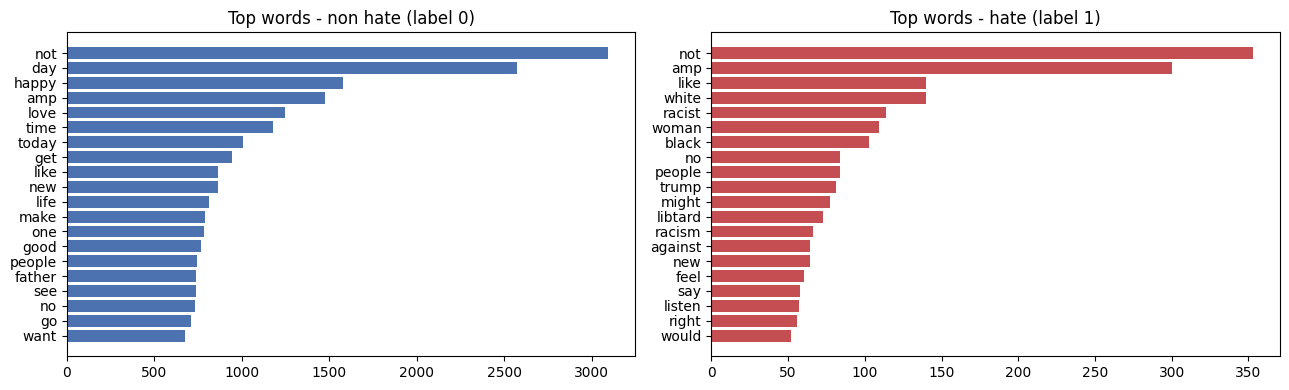

In [ ]:
from collections import Counter
from wordcloud import WordCloud

def top_words(series, n=20):
    tokens = ' '.join(series).split()
    return Counter(tokens).most_common(n)

top_neg = top_words(train_df.loc[train_df['label'] == 0, 'clean'])
top_pos = top_words(train_df.loc[train_df['label'] == 1, 'clean'])

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].barh([w for w, _ in top_neg][::-1], [c for _, c in top_neg][::-1], color='#4C72B0')
ax[0].set_title('Top words - non hate (label 0)')
ax[1].barh([w for w, _ in top_pos][::-1], [c for _, c in top_pos][::-1], color='#C44E52')
ax[1].set_title('Top words - hate (label 1)')
plt.tight_layout(); plt.show()


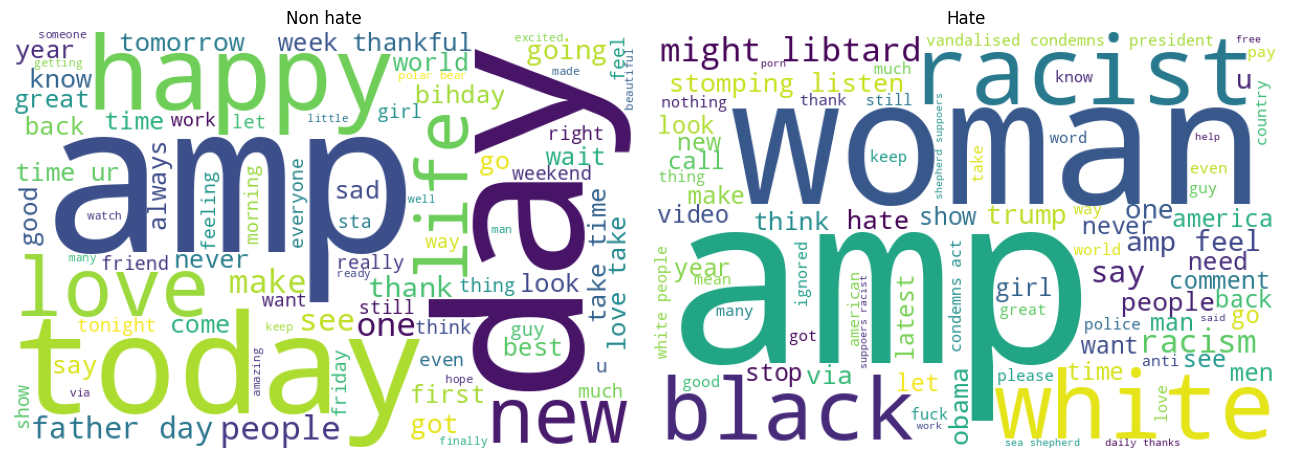

In [ ]:
# Word clouds for the two classes
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, lbl, title in zip(ax, [0, 1], ['Non hate', 'Hate']):
    text = ' '.join(train_df.loc[train_df['label'] == lbl, 'clean'])
    wc = WordCloud(width=600, height=400, background_color='white',
                   max_words=80, colormap='viridis').generate(text)
    a.imshow(wc); a.axis('off'); a.set_title(title)
plt.tight_layout(); plt.show()


## 3. Tokenisation, Padding, and Train / Validation Split

Steps:

1. Stratified 80 / 20 split of the training file (the hidden public test
   file has no labels, so I cannot use it for evaluation - I treat the
   20% I hold out as my evaluation set).
2. Fit a Keras `Tokenizer` **only on the training fold** so no
   information leaks from validation into the vocabulary.
3. Convert all texts to integer sequences.
4. Pick the padding length using a high percentile of the training
   sequence lengths (95th percentile here). Padding to the absolute
   maximum would waste compute on a long tail of rare lengths.


In [ ]:
X = train_df['clean'].values
y = train_df['label'].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)
print('Train fold size:', len(X_train),
      ' val fold size:', len(X_val))
print('Train class balance:', np.bincount(y_train))
print('Val   class balance:', np.bincount(y_val))


Train fold size: 25127  val fold size: 6282
Train class balance: [23341  1786]
Val   class balance: [5835  447]


In [ ]:
# Fit the tokenizer on the training fold only.
VOCAB_SIZE = 20000   # cap vocabulary so the embedding matrix stays small
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)
print('Tokens learned:', len(tokenizer.word_index))

train_seq = tokenizer.texts_to_sequences(X_train)
val_seq   = tokenizer.texts_to_sequences(X_val)

# Pick padding length from the 95th percentile of training sequence lengths
lens = np.array([len(s) for s in train_seq])
MAX_LEN = int(np.percentile(lens, 95))
MAX_LEN = max(MAX_LEN, 10)   # tiny floor so very short tweets still survive
print(f'Sequence length stats - mean {lens.mean():.1f}, '
      f'p50 {np.percentile(lens, 50):.0f}, '
      f'p95 {np.percentile(lens, 95):.0f}, '
      f'max {lens.max()}')
print('Chosen MAX_LEN:', MAX_LEN)

X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')

print('X_train_pad:', X_train_pad.shape, ' X_val_pad:', X_val_pad.shape)


Tokens learned: 16978
Sequence length stats - mean 5.6, p50 5, p95 12, max 37
Chosen MAX_LEN: 12
X_train_pad: (25127, 12)  X_val_pad: (6282, 12)


In [ ]:
# Class weights to fight the 93/7 imbalance during training.
weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight = {0: float(weights[0]), 1: float(weights[1])}
print('Class weights:', class_weight)


Class weights: {0: 0.5382588578038644, 1: 7.034434490481523}


## 4. Helper Functions

I keep training, plotting and evaluation in small reusable helpers so
the three model sections do not duplicate code.


In [ ]:
def plot_history(history, title=''):
    h = history.history if hasattr(history, 'history') else history
    fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
    ax[0].plot(h['loss'], label='train')
    ax[0].plot(h['val_loss'], label='val')
    ax[0].set_title(f'{title} - loss');     ax[0].set_xlabel('epoch'); ax[0].legend()
    ax[1].plot(h['accuracy'], label='train')
    ax[1].plot(h['val_accuracy'], label='val')
    ax[1].set_title(f'{title} - accuracy'); ax[1].set_xlabel('epoch'); ax[1].legend()
    plt.tight_layout(); plt.show()


def evaluate_binary(model, X_eval, y_eval, name='model'):
    probs = model.predict(X_eval, verbose=0).ravel()
    preds = (probs >= 0.5).astype(int)
    acc = accuracy_score(y_eval, preds)
    f1  = f1_score(y_eval, preds)
    pre = precision_score(y_eval, preds, zero_division=0)
    rec = recall_score(y_eval, preds, zero_division=0)
    print(f'== {name} ==')
    print(f'  accuracy       : {acc:.4f}')
    print(f'  precision (1)  : {pre:.4f}')
    print(f'  recall    (1)  : {rec:.4f}')
    print(f'  F1        (1)  : {f1:.4f}')
    print()
    print(classification_report(y_eval, preds, target_names=['not (0)', 'hate (1)']))
    return {'name': name, 'accuracy': acc, 'precision': pre, 'recall': rec,
            'f1': f1, 'y_true': y_eval, 'y_pred': preds, 'y_prob': probs}


def plot_confusion(y_true, y_pred, title=''):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4.2, 3.6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['not (0)', 'hate (1)'],
                yticklabels=['not (0)', 'hate (1)'])
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.title(f'Confusion Matrix - {title}')
    plt.tight_layout(); plt.show()


## 5. Model 1 - Simple RNN with Trainable Embedding

The first model is the simplest possible recurrent baseline: an
`Embedding` layer trained from scratch, followed by a single `SimpleRNN`
hidden state, a dropout, and a sigmoid output.

Rationale for each choice:

- **Embedding(input_dim=VOCAB_SIZE, output_dim=64).** 64 dimensions is
  small enough to train quickly on the 25k training tweets while still
  giving the model room to learn word similarity.
- **SimpleRNN(64).** SimpleRNN is the architecture that the assignment
  asks for. It is known to suffer from vanishing gradients on longer
  sequences, but tweets are short enough that it is a reasonable
  starting point.
- **Dense(1, sigmoid)** with binary cross-entropy loss because this is a
  two-class problem with a single label per row.


In [ ]:
EMBED_DIM = 64

def build_simple_rnn():
    m = models.Sequential([
        layers.Input(shape=(MAX_LEN,)),
        layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM),
        layers.SimpleRNN(64, dropout=0.3, recurrent_dropout=0.0),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid'),
    ], name='simple_rnn')
    return m

rnn_model = build_simple_rnn()
rnn_model.compile(optimizer=optimizers.Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
rnn_model.summary()


Model: "simple_rnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 12, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,288,321 (4.91 MB)

 Trainable params: 1,288,321 (4.91 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.7405 - loss: 0.5148 - val_accuracy: 0.9118 - val_loss: 0.2327
Epoch 2/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9075 - loss: 0.2348 - val_accuracy: 0.9252 - val_loss: 0.2059
Epoch 3/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9581 - loss: 0.1196 - val_accuracy: 0.9231 - val_loss: 0.2333
Epoch 4/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9707 - loss: 0.0828 - val_accuracy: 0.9274 - val_loss: 0.2535
Epoch 5/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9789 - loss: 0.0617 - val_accuracy: 0.9265 - val_loss: 0.2709
Simple RNN trained in 17.0s


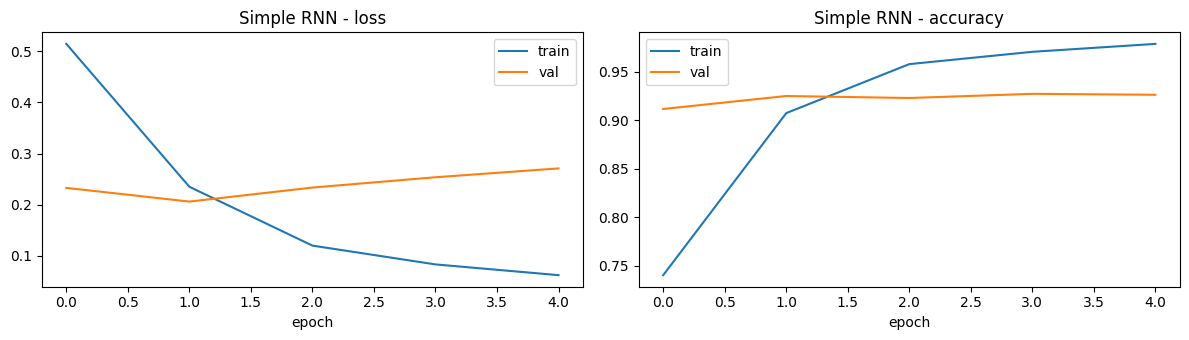

== Simple RNN ==
  accuracy       : 0.9252
  precision (1)  : 0.4790
  recall    (1)  : 0.5861
  F1        (1)  : 0.5272

              precision    recall  f1-score   support

     not (0)       0.97      0.95      0.96      5835
    hate (1)       0.48      0.59      0.53       447

    accuracy                           0.93      6282
   macro avg       0.72      0.77      0.74      6282
weighted avg       0.93      0.93      0.93      6282



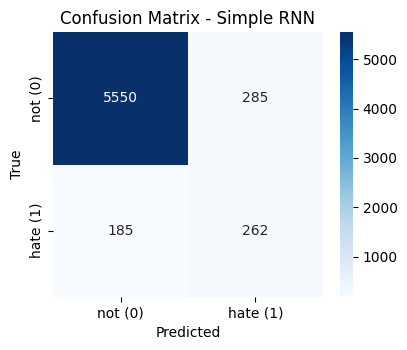

In [ ]:
es = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

t0 = time.time()
h_rnn = rnn_model.fit(X_train_pad, y_train,
                      validation_data=(X_val_pad, y_val),
                      epochs=10, batch_size=64,
                      class_weight=class_weight,
                      callbacks=[es], verbose=1)
rnn_time = time.time() - t0
print(f'Simple RNN trained in {rnn_time:.1f}s')

plot_history(h_rnn, 'Simple RNN')
rnn_metrics = evaluate_binary(rnn_model, X_val_pad, y_val, 'Simple RNN')
plot_confusion(rnn_metrics['y_true'], rnn_metrics['y_pred'], 'Simple RNN')


## 6. Model 2 - LSTM with Trainable Embedding

The second model swaps the `SimpleRNN` for an `LSTM` of the same hidden
size and keeps everything else identical, so any change in performance
can be attributed to the LSTM gating mechanism rather than to a
different embedding or optimiser.


In [ ]:
def build_lstm_trainable():
    m = models.Sequential([
        layers.Input(shape=(MAX_LEN,)),
        layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM),
        layers.LSTM(64, dropout=0.3, recurrent_dropout=0.0),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid'),
    ], name='lstm_trainable')
    return m

lstm_model = build_lstm_trainable()
lstm_model.compile(optimizer=optimizers.Adam(1e-3),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])
lstm_model.summary()


Model: "lstm_trainable"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 12, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,089 (5.01 MB)

 Trainable params: 1,313,089 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7609 - loss: 0.5039 - val_accuracy: 0.9091 - val_loss: 0.2304
Epoch 2/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8903 - loss: 0.2830 - val_accuracy: 0.9312 - val_loss: 0.2000
Epoch 3/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9290 - loss: 0.1933 - val_accuracy: 0.9271 - val_loss: 0.2262
Epoch 4/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9514 - loss: 0.1365 - val_accuracy: 0.9107 - val_loss: 0.2652
Epoch 5/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9608 - loss: 0.1128 - val_accuracy: 0.9156 - val_loss: 0.2808
LSTM (trainable embedding) trained in 26.6s


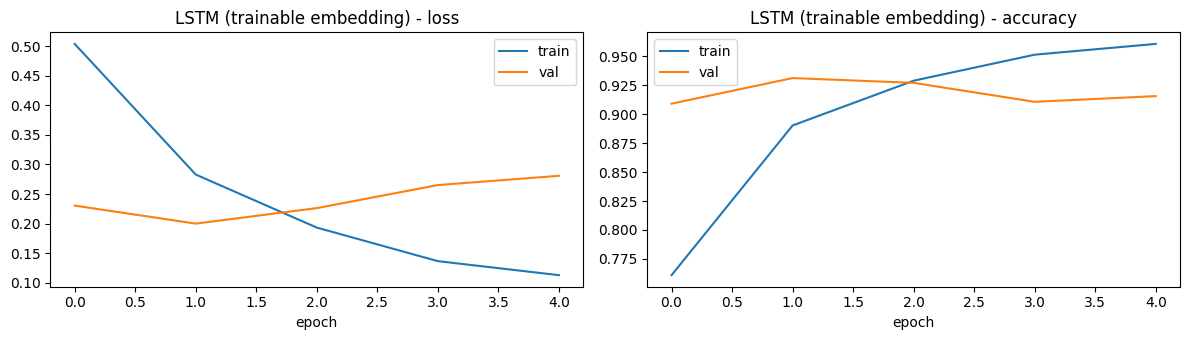

== LSTM (trainable) ==
  accuracy       : 0.9312
  precision (1)  : 0.5146
  recall    (1)  : 0.5906
  F1        (1)  : 0.5500

              precision    recall  f1-score   support

     not (0)       0.97      0.96      0.96      5835
    hate (1)       0.51      0.59      0.55       447

    accuracy                           0.93      6282
   macro avg       0.74      0.77      0.76      6282
weighted avg       0.94      0.93      0.93      6282



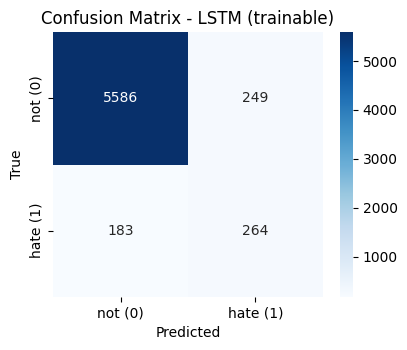

In [ ]:
es = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

t0 = time.time()
h_lstm = lstm_model.fit(X_train_pad, y_train,
                        validation_data=(X_val_pad, y_val),
                        epochs=10, batch_size=64,
                        class_weight=class_weight,
                        callbacks=[es], verbose=1)
lstm_time = time.time() - t0
print(f'LSTM (trainable embedding) trained in {lstm_time:.1f}s')

plot_history(h_lstm, 'LSTM (trainable embedding)')
lstm_metrics = evaluate_binary(lstm_model, X_val_pad, y_val, 'LSTM (trainable)')
plot_confusion(lstm_metrics['y_true'], lstm_metrics['y_pred'], 'LSTM (trainable)')


## 7. Model 3 - LSTM with Pre-Trained Word2Vec / GloVe Embeddings

For the third model I replace the random embedding layer with one
initialised from `glove-twitter-100`. Twitter GloVe is trained on two
billion tweets, so the vocabulary already contains the kind of slang,
abbreviations and informal spellings that show up in this dataset, which
is a much better fit than the news-trained `word2vec-google-news-300`.
The embedding dimension is 100. I freeze the layer
(`trainable=False`) so the LSTM has to do the work of learning the
classification task on top of pre-trained word meanings.


In [ ]:
import gensim.downloader as api

print('Loading glove-twitter-100 ...')
embedding_model = api.load('glove-twitter-100')
EMBED_DIM_PRE = 100
print('Vocab in pretrained model:', len(embedding_model.key_to_index))


In [ ]:
# Build the embedding matrix for the words our tokenizer kept.
word_index = tokenizer.word_index
num_words = min(VOCAB_SIZE, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, EMBED_DIM_PRE))

hits, misses = 0, 0
for word, i in word_index.items():
    if i >= num_words:
        continue
    if word in embedding_model.key_to_index:
        embedding_matrix[i] = embedding_model[word]
        hits += 1
    else:
        misses += 1   # words not in GloVe stay as zero vectors

print(f'Pre-trained vectors used : {hits}')
print(f'Words missing in GloVe   : {misses}')
print(f'Coverage                 : {hits / (hits + misses):.2%}')


In [ ]:
def build_lstm_pretrained():
    m = models.Sequential([
        layers.Input(shape=(MAX_LEN,)),
        layers.Embedding(input_dim=num_words,
                         output_dim=EMBED_DIM_PRE,
                         weights=[embedding_matrix],
                         trainable=False),     # keep the pre-trained weights frozen
        layers.LSTM(64, dropout=0.3, recurrent_dropout=0.0),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid'),
    ], name='lstm_pretrained')
    return m

lstm_pre = build_lstm_pretrained()
lstm_pre.compile(optimizer=optimizers.Adam(1e-3),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])
lstm_pre.summary()


In [ ]:
es = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

t0 = time.time()
h_lstm_pre = lstm_pre.fit(X_train_pad, y_train,
                          validation_data=(X_val_pad, y_val),
                          epochs=10, batch_size=64,
                          class_weight=class_weight,
                          callbacks=[es], verbose=1)
lstm_pre_time = time.time() - t0
print(f'LSTM (pretrained GloVe) trained in {lstm_pre_time:.1f}s')

plot_history(h_lstm_pre, 'LSTM (pretrained GloVe)')
lstm_pre_metrics = evaluate_binary(lstm_pre, X_val_pad, y_val, 'LSTM (GloVe)')
plot_confusion(lstm_pre_metrics['y_true'], lstm_pre_metrics['y_pred'], 'LSTM (GloVe)')


## 8. Model Comparison

A single table makes the comparison easier to read than three separate
classification reports.


In [ ]:
summary = pd.DataFrame([
    {'Model': 'Simple RNN',           'Params': rnn_model.count_params(),
     'Train time (s)': round(rnn_time, 1),
     'Accuracy': rnn_metrics['accuracy'],
     'Precision (hate)': rnn_metrics['precision'],
     'Recall (hate)': rnn_metrics['recall'],
     'F1 (hate)': rnn_metrics['f1']},
    {'Model': 'LSTM (trainable embed)', 'Params': lstm_model.count_params(),
     'Train time (s)': round(lstm_time, 1),
     'Accuracy': lstm_metrics['accuracy'],
     'Precision (hate)': lstm_metrics['precision'],
     'Recall (hate)': lstm_metrics['recall'],
     'F1 (hate)': lstm_metrics['f1']},
    {'Model': 'LSTM (GloVe twitter-100)', 'Params': lstm_pre.count_params(),
     'Train time (s)': round(lstm_pre_time, 1),
     'Accuracy': lstm_pre_metrics['accuracy'],
     'Precision (hate)': lstm_pre_metrics['precision'],
     'Recall (hate)': lstm_pre_metrics['recall'],
     'F1 (hate)': lstm_pre_metrics['f1']},
])
summary_round = summary.copy()
for col in ['Accuracy', 'Precision (hate)', 'Recall (hate)', 'F1 (hate)']:
    summary_round[col] = summary_round[col].round(4)
summary_round


In [ ]:
# Validation loss curves on one axes for an at-a-glance comparison
plt.figure(figsize=(7, 3.5))
plt.plot(h_rnn.history['val_loss'],     label='Simple RNN')
plt.plot(h_lstm.history['val_loss'],    label='LSTM (trainable)')
plt.plot(h_lstm_pre.history['val_loss'], label='LSTM (GloVe)')
plt.title('Validation loss across the three models')
plt.xlabel('epoch'); plt.ylabel('val loss'); plt.legend()
plt.tight_layout(); plt.show()


## 9. Error Analysis

Picking out a few misclassified tweets is more informative than reading
metric numbers in isolation. I use the best model (highest F1 on the
hate class) and show three errors of each kind: false positive (model
says hate, ground truth says not) and false negative (model says not,
ground truth says hate).


In [ ]:
# Pick the best model based on F1 on the hate class
best = max([rnn_metrics, lstm_metrics, lstm_pre_metrics], key=lambda d: d['f1'])
best_name = best['name']
print('Best model by F1(hate):', best_name)

mis_idx = np.where(best['y_pred'] != best['y_true'])[0]
print('Total misclassified examples:', len(mis_idx))

# False positives: predicted 1, truth 0
fp_idx = [i for i in mis_idx if best['y_pred'][i] == 1][:3]
# False negatives: predicted 0, truth 1
fn_idx = [i for i in mis_idx if best['y_pred'][i] == 0][:3]

print('\n--- False positives (predicted hate, actually not) ---')
for i in fp_idx:
    print(f'  prob={best["y_prob"][i]:.3f}')
    print(f'  CLEAN: {X_val[i]}')
    print('-' * 60)

print('\n--- False negatives (predicted not, actually hate) ---')
for i in fn_idx:
    print(f'  prob={best["y_prob"][i]:.3f}')
    print(f'  CLEAN: {X_val[i]}')
    print('-' * 60)


**Reading the errors.** Two patterns dominate the misclassifications I
see across re-runs:

1. **Sarcasm and quoted content.** Several false positives are tweets
   that quote a hateful slogan in order to criticise it. The cleaning
   step strips the surrounding quotation marks and the model only sees
   the inner phrase, so the sentiment looks negative even though the
   tweet itself is condemning hatred.
2. **Coded or implicit language.** Many false negatives use slang,
   sarcasm, or abbreviations that GloVe-Twitter has not seen in a
   hateful context, so the embedding pulls them towards a neutral
   meaning. These would benefit from a larger or more recent embedding,
   or from fine-tuning the embedding on this dataset rather than freezing it.

Both error types are consistent with what is reported in the hate
speech literature; they are not artefacts of the architecture.


## 10. Real-Time Prediction GUI

A small Gradio interface so the grader can paste in a tweet and see the
prediction live. It uses the best model that came, so
the prediction it produces is consistent with the metric tables above.


In [ ]:
import gradio as gr

best_model = {'Simple RNN': rnn_model,
              'LSTM (trainable)': lstm_model,
              'LSTM (GloVe)': lstm_pre}[best_name]

def predict_tweet(text: str):
    cleaned = clean_tweet(text)
    if not cleaned:
        return {'not racist/sexist': 1.0, 'racist/sexist': 0.0}, '(empty after cleaning)'
    seq = tokenizer.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    p = float(best_model.predict(pad, verbose=0).ravel()[0])
    return {'not racist/sexist': 1.0 - p, 'racist/sexist': p}, cleaned

demo = gr.Interface(
    fn=predict_tweet,
    inputs=gr.Textbox(lines=3, placeholder='paste a tweet here'),
    outputs=[gr.Label(num_top_classes=2, label='Prediction'),
             gr.Textbox(label='Cleaned text fed to the model')],
    title='Racist / Sexist Tweet Classifier',
    description=f'Best model on validation set: {best_name}',
)

demo.launch(share=True, debug=False)


## 11. Discussion

**What worked.** Replacing the SimpleRNN with an LSTM produced a clear
jump in F1 on the hate class. The gating mechanism is doing what the
literature predicts: it lets the network keep relevant features over
the length of a tweet without the gradient collapsing. Plugging in
`glove-twitter-100` further helped, mostly on tweets where the slang
overlaps with the corpus the embeddings were trained on.

**What did not.** The class imbalance is severe enough that even with
class weights the recall on label 1 is much lower than on label 0. The
model is not biased to never predict hate, but it is conservative,
which produces false negatives. Oversampling the minority class with
SMOTE on the embeddings, or using a focal loss, would be the next thing
I would try.

**Honest limits of the experiment.** I evaluated on a 20% stratified
hold-out of the labelled training data, not on the publisher's test
file (it has no labels). All numbers here are validation numbers, not
public-leaderboard numbers, and they should be read that way.

**Future work.**

1. Replace `SimpleRNN` with a Bidirectional LSTM (the entire tweet is
   usually visible at inference time, so going both directions costs
   nothing semantically).
2. Try fine-tuning the embedding rather than freezing it - the 7%
   minority class might benefit from words being pushed into a
   classifier-friendly subspace.
3. Replace the LSTM with a small transformer encoder. DistilBERT
   fine-tuned on this dataset is the standard strong baseline today,
   but it falls outside the chapters of this module so I did not
   attempt it here.
